# Explainability (XAI) — Feature Importance & Error Analysis

This notebook loads the LOSO results from `04-models.ipynb` and performs:
- Permutation feature importance
- SHAP summary (beeswarm/bar) plots
- SHAP force plots (per-sample explanations)
- Per-subject error analysis

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.models import load_loso_results
from src.explainability import (
    compute_permutation_importance,
    plot_permutation_importance,
    compute_shap_values,
    plot_shap_summary,
    plot_shap_bar,
    plot_force_plot,
    plot_force_plot_grid,
    plot_subject_error_analysis,
    plot_confusion_matrix_grid,
)
from src.evaluation import compute_subject_error_analysis

FIGURES_DIR = Path("../experiments/run_001/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Imports ready. Figures path:", FIGURES_DIR.resolve())

Imports ready. Figures path: /home/fjg/raspnas/personal/education/university/courses/third_year/healthcare/final_project/wesad-wrist-stress-prediction/experiments/run_001/figures


In [2]:
# Load precomputed LOSO results from 04-models.ipynb
LOSO_PATH = Path("../experiments/run_001/loso_results")
loaded = load_loso_results(LOSO_PATH)

results = loaded["results"]
X = loaded["X"]
y = loaded["y"]
subject = loaded["subject"]
feature_names = loaded["feature_names"]

print(f"Loaded {len(results)} models")
print(f"X: {X.shape}, y: {y.shape}, subjects: {len(np.unique(subject))}")
print("Models:", list(results.keys()))

Loaded 6 models
X: (132474, 51), y: (132474,), subjects: 15
Models: ['SVM', 'SVM Tuned', 'Logistic Regression', 'Logistic Regression Tuned', 'MLP', 'LSTM']


## Permutation Feature Importance

Evaluates how much each feature contributes to accuracy by shuffling it and measuring the drop.

In [3]:
# Retrain best model on full data for permutation importance
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif

best_model_name = "MLP"
from src.models import get_enhanced_models

models = get_enhanced_models(random_state=42, backend="cpu")
best_model = models[best_model_name]

# Apply the same feature pipeline as in training: robust scaler + k=24 f_classif
scaler = RobustScaler()
selector = SelectKBest(score_func=f_classif, k=24)

X_scaled = scaler.fit_transform(X)
X_selected = selector.fit_transform(X_scaled, y)
selected_feature_names = [feature_names[i] for i in selector.get_support(indices=True)]

clf = models[best_model_name]
clf.fit(X_selected, y)
print(f"Fitted {best_model_name} on full data ({X_selected.shape[1]} features)")

Fitted MLP on full data (24 features)


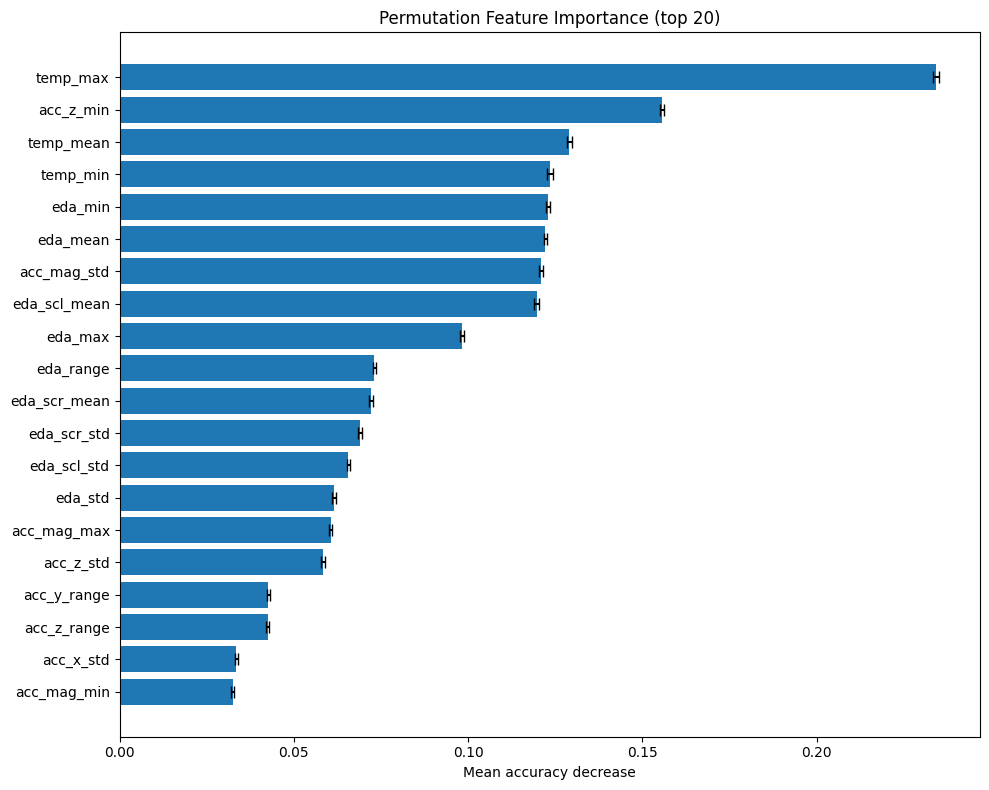

,feature,importance_mean,importance_std
0,temp_max,0.234170,0.000935
1,acc_z_min,0.155589,0.000655
2,temp_mean,0.128960,0.000730
3,temp_min,0.123360,0.000865
4,eda_min,0.122879,0.000635
5,eda_mean,0.122117,0.000483
6,acc_mag_std,0.120872,0.000465
7,eda_scl_mean,0.119646,0.000706
8,eda_max,0.098228,0.000547
9,eda_range,0.073069,0.000427


Saved permutation importance plot to: ../experiments/run_001/figures/permutation_importance.png


In [4]:
perm_imp_df = compute_permutation_importance(
    clf, X_selected, y,
    feature_names=selected_feature_names,
    n_repeats=10,
    random_state=42,
    scoring="accuracy",
)

perm_imp_path = FIGURES_DIR / "permutation_importance.png"
plot_permutation_importance(perm_imp_df, perm_imp_path, top_n=20)

display(perm_imp_df.head(10))
print(f"Saved permutation importance plot to: {perm_imp_path}")

## SHAP Explanations

Compute SHAP values using KernelExplainer (model-agnostic).

In [5]:
print("Computing SHAP values (this may take a while)...")

shap_values, X_shap = compute_shap_values(
    model=clf,
    X_explain=X_selected,
    X_background=None,
    n_background=100,
    random_state=42,
)

n_classes = len(shap_values) if isinstance(shap_values, list) else 1
print(f"SHAP values computed. Shape per class: {[sv.shape for sv in shap_values]}")
print(f"Classes: {n_classes}")

class_names = ["Baseline", "Stress", "Amusement"]

Computing SHAP values (this may take a while)...


  0%|          | 0/200 [00:00<?, ?it/s]

SHAP values computed. Shape per class: [(24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3), (24, 3

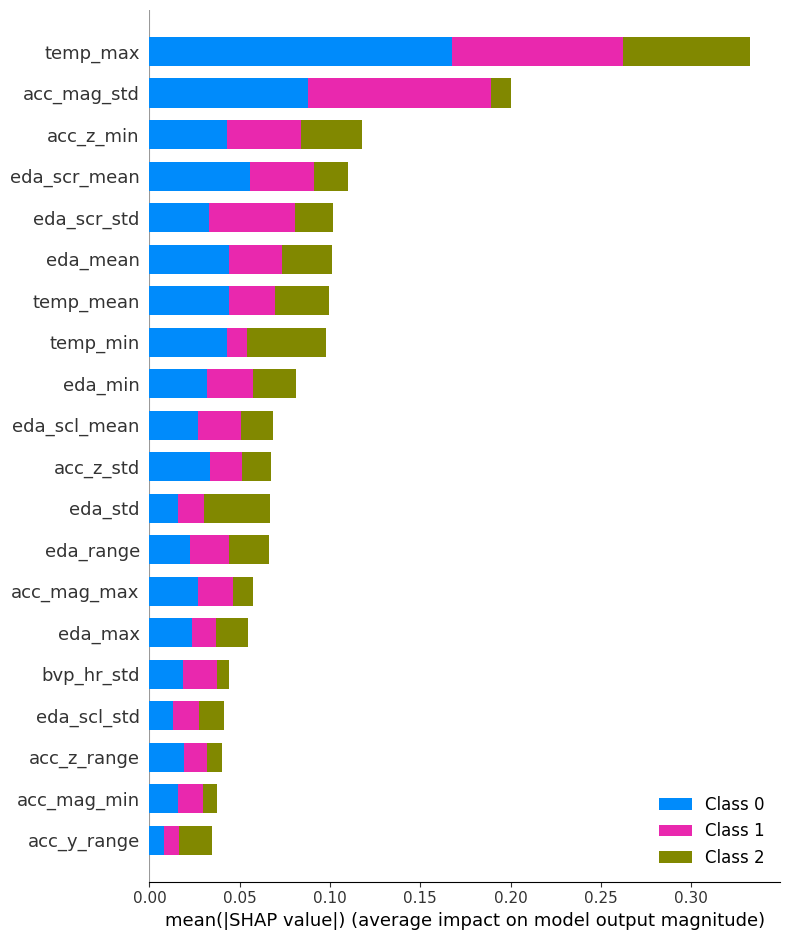

Saved SHAP bar plot to: ../experiments/run_001/figures/shap_bar_global.png


In [6]:
# SHAP bar plot (mean |SHAP| per feature, global)
# Use the first class's SHAP values for the bar plot (all classes have same shape)
# The bar plot shows mean |SHAP| per feature across all samples
shap_for_bar = shap_values[0] if isinstance(shap_values, list) else shap_values

shap_bar_path = FIGURES_DIR / "shap_bar_global.png"
plot_shap_bar(
    shap_for_bar, X_shap,
    feature_names=selected_feature_names,
    output_path=shap_bar_path,
    max_display=20,
)

print(f"Saved SHAP bar plot to: {shap_bar_path}")

## SHAP Force Plots (Per-Sample Explanations)

Explaining individual predictions to understand model behaviour on specific samples.

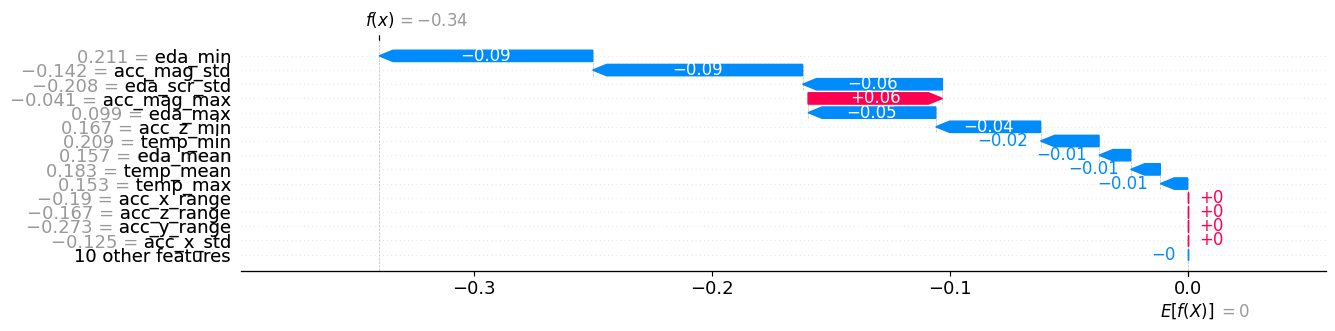

Saved force plot for sample 102 to: ../experiments/run_001/figures/force_plot_sample_102.png


In [7]:
# Force plot for a single sample (Stress class explanation)
rng = np.random.RandomState(42)
sample_idx = rng.randint(0, len(X_shap))
# reload module to ensure latest changes are reflected in the notebook
force_plot_path = FIGURES_DIR / f"force_plot_sample_{sample_idx}.png"
plot_force_plot(
    shap_values, X_shap[sample_idx],
    feature_names=selected_feature_names,
    output_path=force_plot_path,
    class_index=1,  # Stress class
    figsize=(14, 3),
)

print(f"Saved force plot for sample {sample_idx} to: {force_plot_path}")

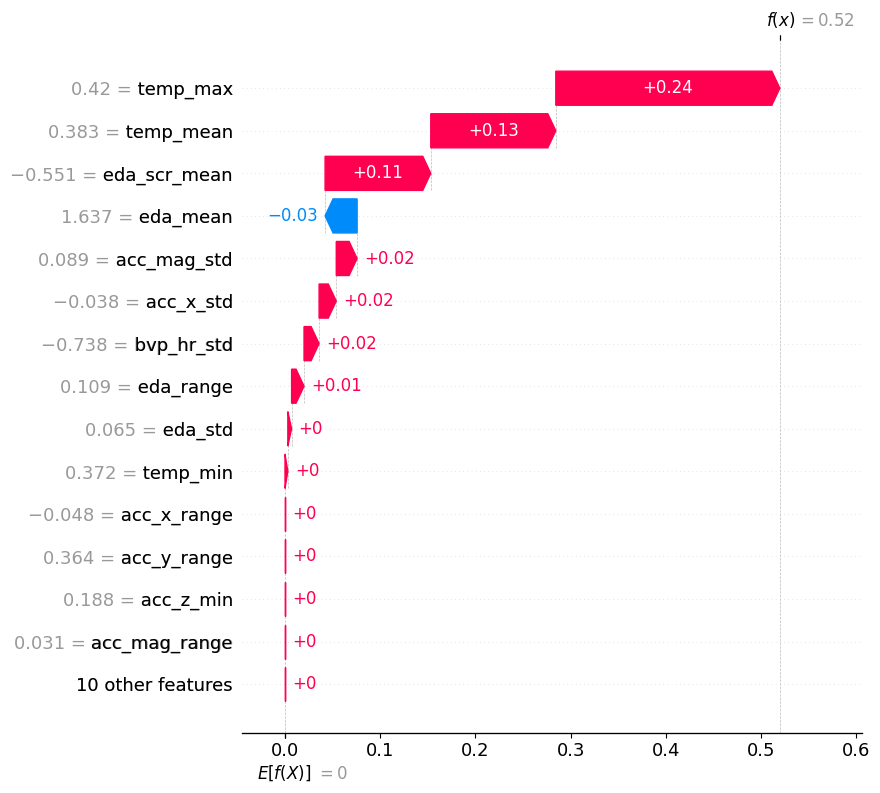

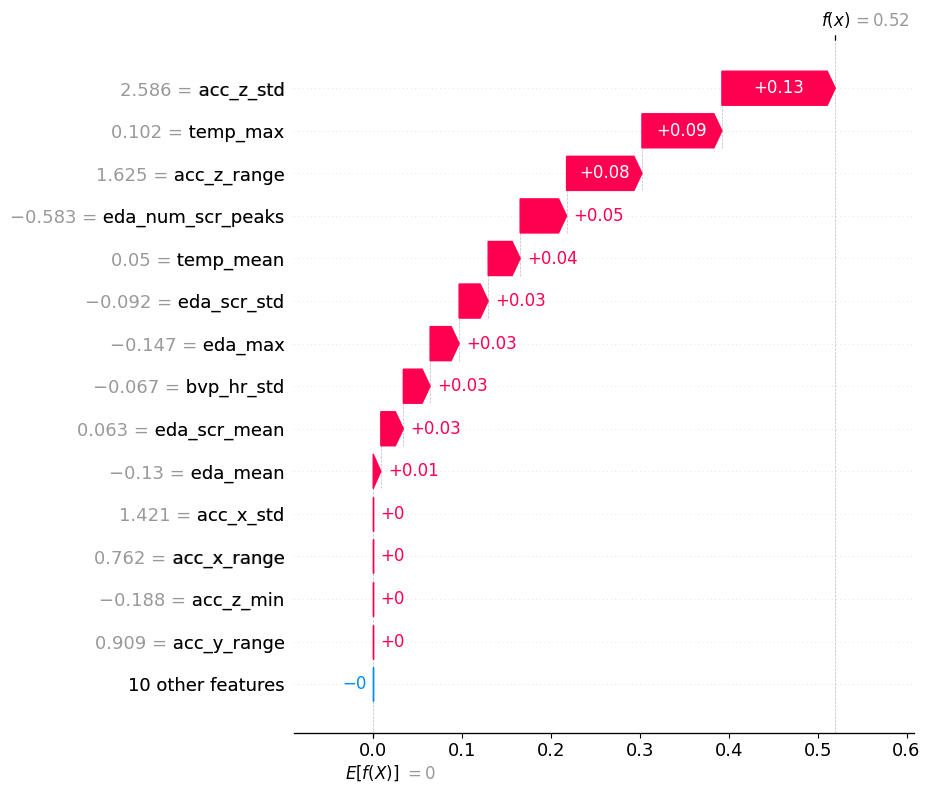

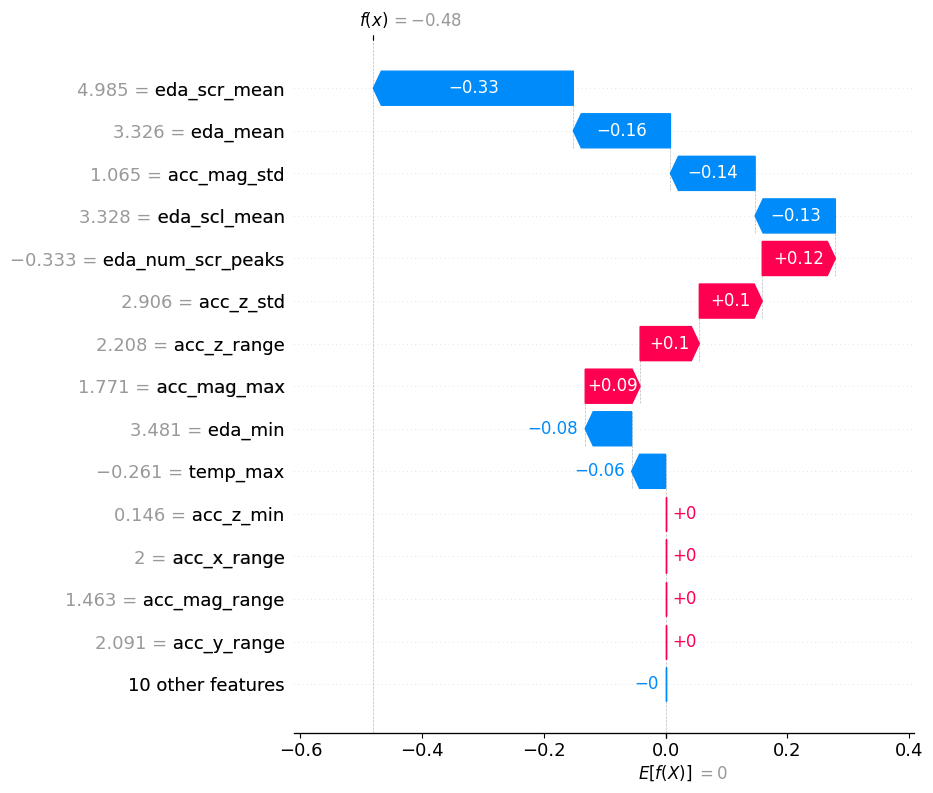

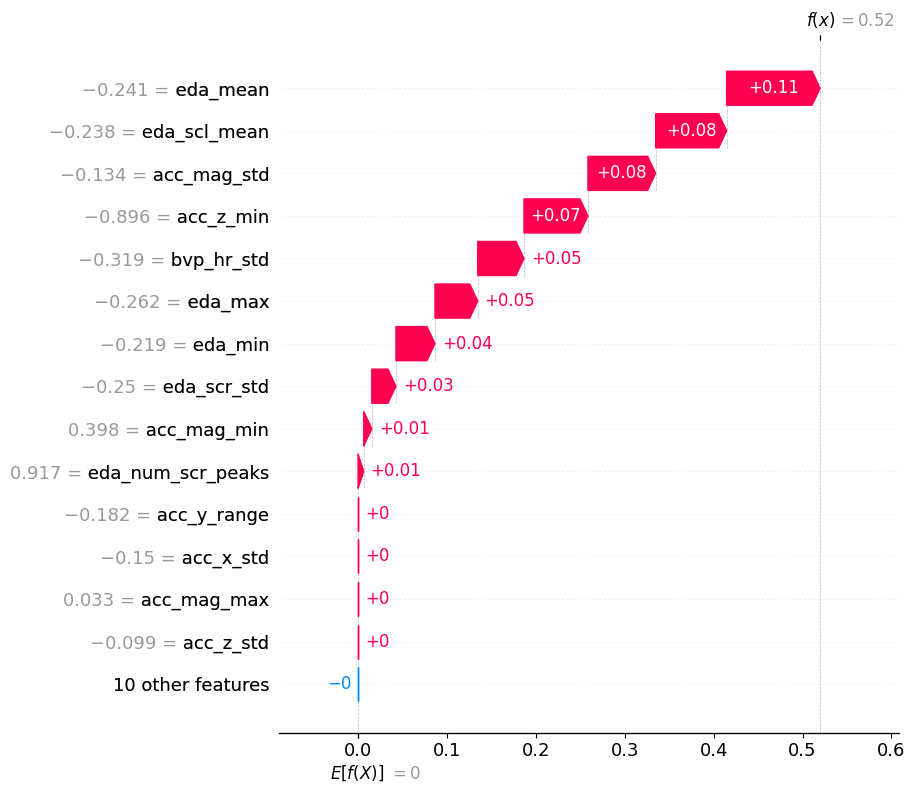

Saved force plots to: ../experiments/run_001/figures/force_plots


In [8]:
# Force plot grid: multiple samples per class
force_grid_dir = FIGURES_DIR / "force_plots"
plot_force_plot_grid(
    shap_values, X_shap,
    feature_names=selected_feature_names,
    output_path=force_grid_dir,
    class_names=class_names,
    n_samples=4,
    random_state=42,
)

print(f"Saved force plots to: {force_grid_dir}")

## Error Analysis

Per-subject misclassification analysis to identify which subjects the models struggle with most.


=== SVM — Worst 3 Subjects ===


,subject,error_rate,n_errors,support,misclass_details
0,6,0.5168,4552,8808,"true=1 [pred→2:1192, pred→3:60]; true=2 [pred→..."
1,3,0.4987,4299,8620,"true=1 [pred→2:1446, pred→3:715]; true=2 [pred..."
2,15,0.3833,3424,8932,"true=1 [pred→3:1567, pred→2:46]; true=2 [pred→..."


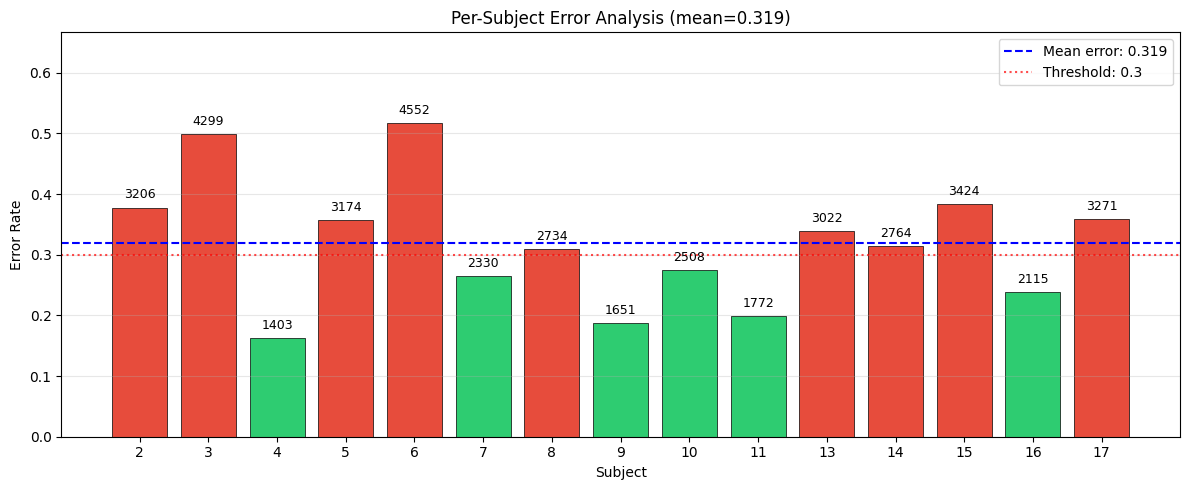

Saved error plot: ../experiments/run_001/figures/error_analysis_svm.png

=== SVM Tuned — Worst 3 Subjects ===


,subject,error_rate,n_errors,support,misclass_details
0,8,0.5545,4900,8836,"true=1 [pred→2:1515, pred→3:581]; true=2 [pred..."
1,6,0.5404,4760,8808,"true=1 [pred→2:1115, pred→3:148]; true=2 [pred..."
2,3,0.4903,4226,8620,"true=1 [pred→2:1341, pred→3:804]; true=2 [pred..."


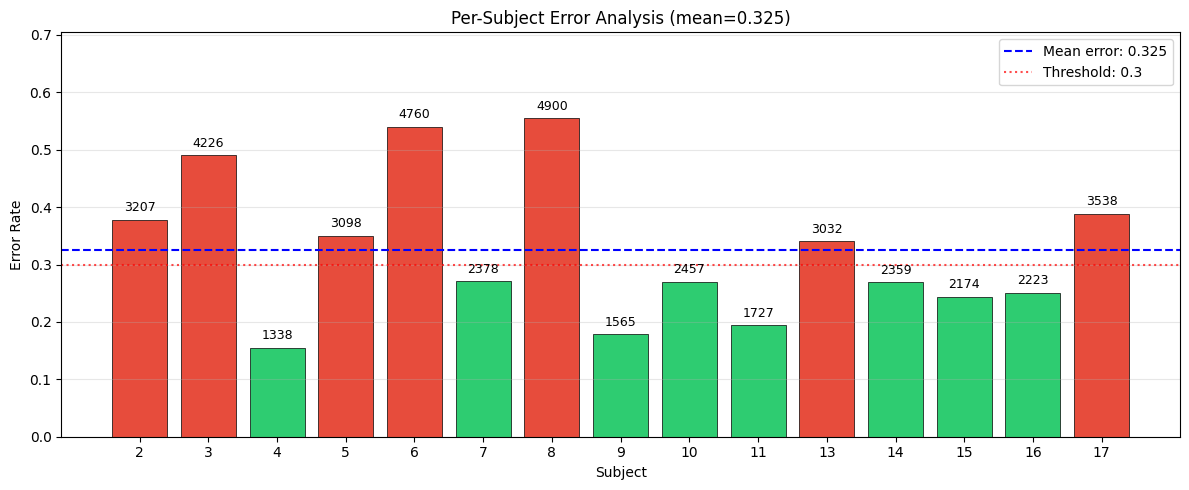

Saved error plot: ../experiments/run_001/figures/error_analysis_svm_tuned.png

=== Logistic Regression — Worst 3 Subjects ===


,subject,error_rate,n_errors,support,misclass_details
0,15,0.6418,5733,8932,"true=1 [pred→3:2529, pred→2:1443]; true=2 [pre..."
1,3,0.4658,4015,8620,"true=1 [pred→2:1087, pred→3:215]; true=2 [pred..."
2,16,0.4587,4075,8884,"true=1 [pred→3:1525, pred→2:1195]; true=2 [pre..."


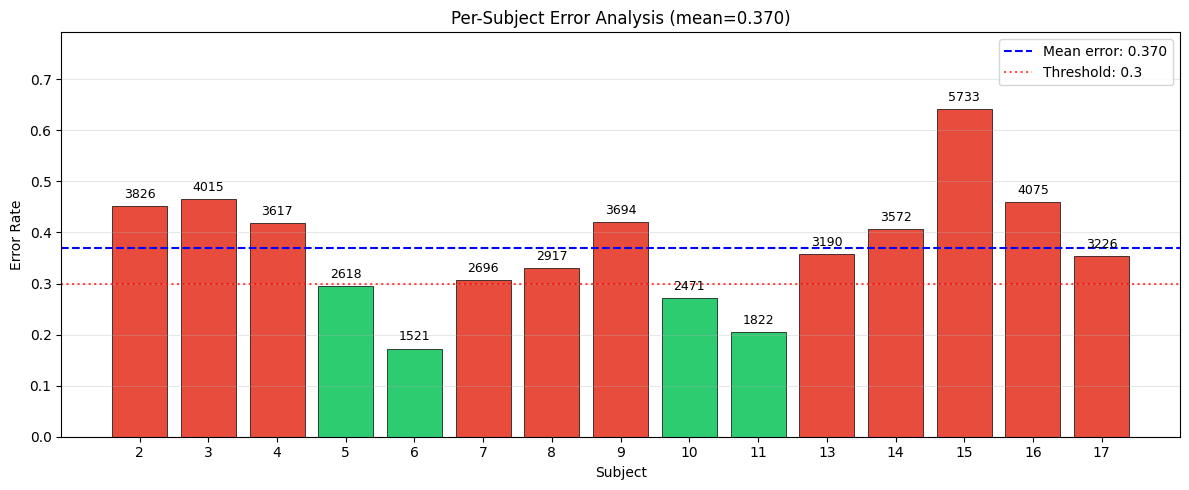

Saved error plot: ../experiments/run_001/figures/error_analysis_logistic_regression.png

=== Logistic Regression Tuned — Worst 3 Subjects ===


,subject,error_rate,n_errors,support,misclass_details
0,15,0.6411,5726,8932,"true=1 [pred→3:2510, pred→2:1448]; true=2 [pre..."
1,3,0.4644,4003,8620,"true=1 [pred→2:1085, pred→3:215]; true=2 [pred..."
2,16,0.4576,4065,8884,"true=1 [pred→3:1510, pred→2:1207]; true=2 [pre..."


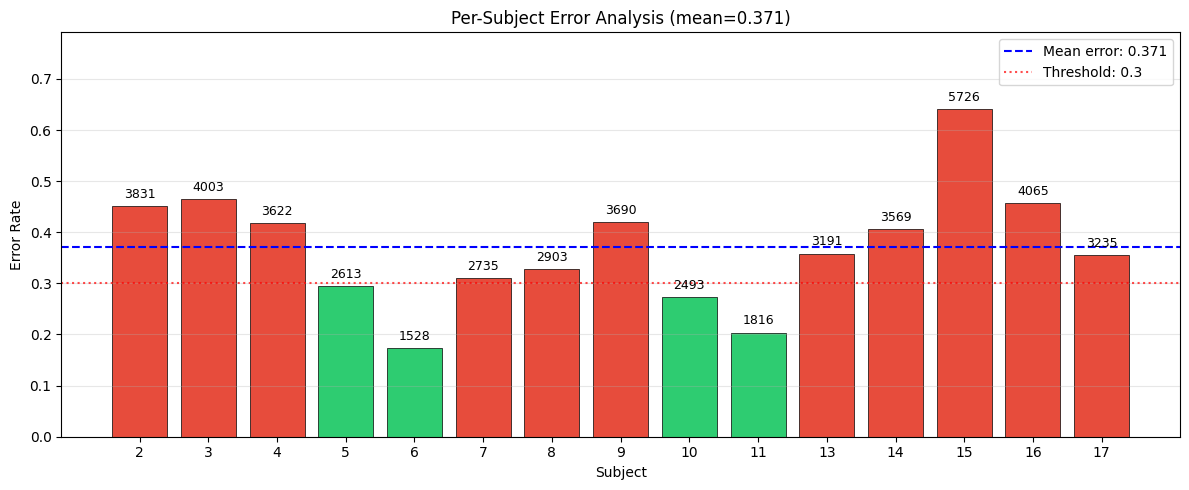

Saved error plot: ../experiments/run_001/figures/error_analysis_logistic_regression_tuned.png

=== MLP — Worst 3 Subjects ===


,subject,error_rate,n_errors,support,misclass_details
0,3,0.4821,4156,8620,"true=1 [pred→2:1663, pred→3:556]; true=2 [pred..."
1,2,0.4619,3919,8484,true=1 [pred→3:1296]; true=2 [pred→1:1521]; tr...
2,6,0.4327,3811,8808,"true=1 [pred→2:1318, pred→3:416]; true=2 [pred..."


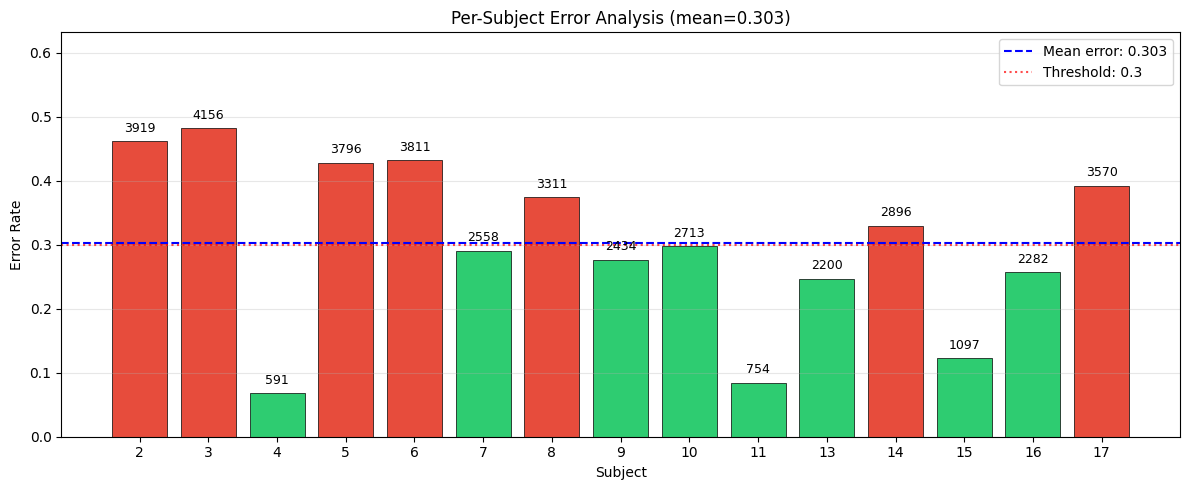

Saved error plot: ../experiments/run_001/figures/error_analysis_mlp.png

=== LSTM — Worst 3 Subjects ===


,subject,error_rate,n_errors,support,misclass_details
0,17,0.4941,4495,9097,"true=1 [pred→2:2419]; true=2 [pred→1:354, pred..."
1,5,0.4586,4064,8861,"true=1 [pred→2:372, pred→3:219]; true=2 [pred→..."
2,14,0.4412,3868,8767,"true=1 [pred→3:2361, pred→2:8]; true=2 [pred→1..."


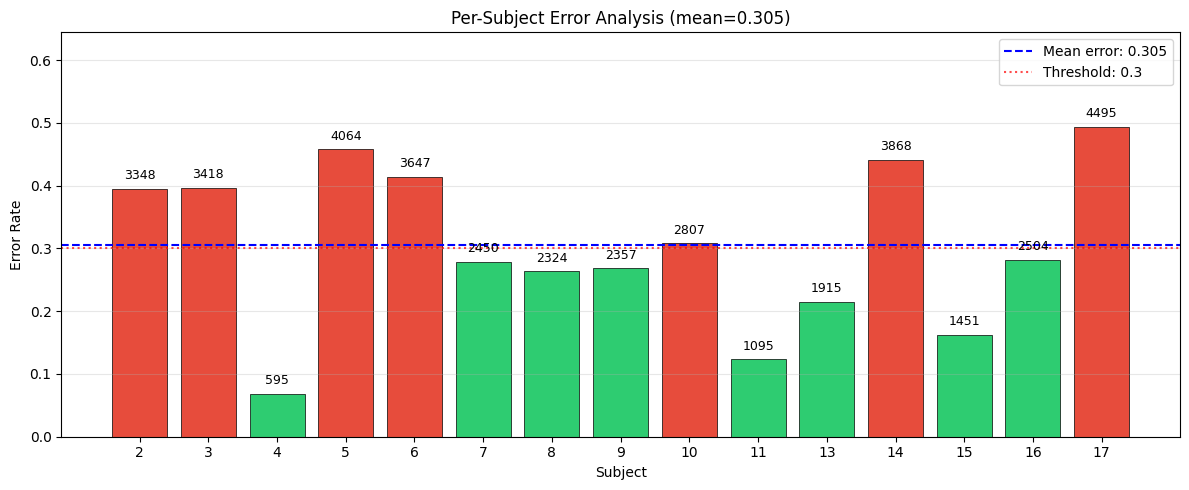

Saved error plot: ../experiments/run_001/figures/error_analysis_lstm.png


In [9]:
# Per-subject error analysis for each model
for model_name, result in results.items():
    yt = np.array(result["y_true"])
    yp = np.array(result["y_pred"])
    subj = np.array(result["subject"])

    err_df = compute_subject_error_analysis(yt, yp, subj)
    worst = err_df.nlargest(3, "error_rate")

    print(f"\n=== {model_name} — Worst 3 Subjects ===")
    display(worst[["subject", "error_rate", "n_errors", "support", "misclass_details"]].reset_index(drop=True))

    plot_path = FIGURES_DIR / f"error_analysis_{model_name.lower().replace(' ', '_')}.png"
    plot_subject_error_analysis(err_df, plot_path, threshold=0.3)
    print(f"Saved error plot: {plot_path}")

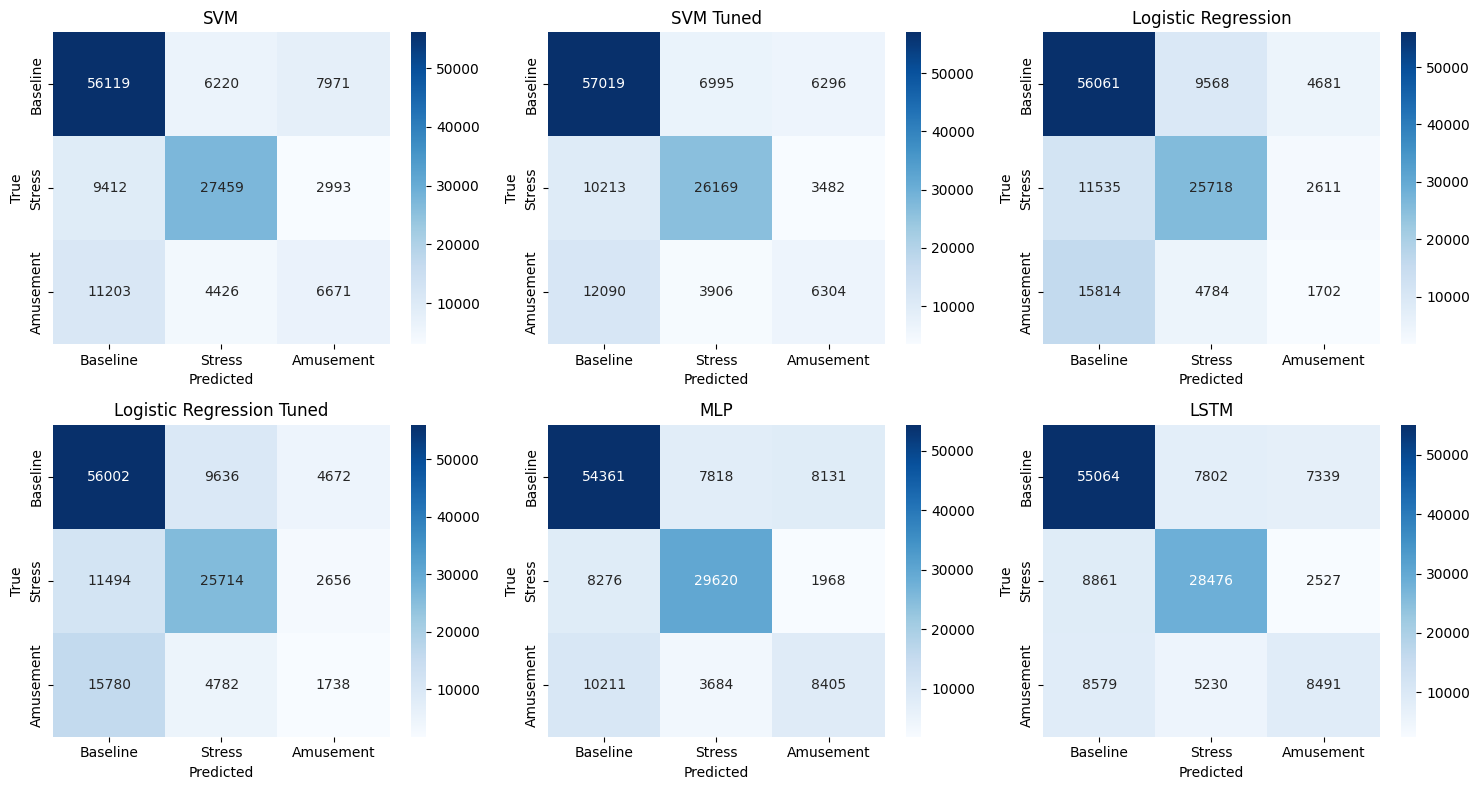

Saved confusion matrices: ../experiments/run_001/figures/confusion_matrices_xai.png


In [10]:
# Confusion matrices for reference
cm_path = FIGURES_DIR / "confusion_matrices_xai.png"
plot_confusion_matrix_grid(results, cm_path)
print(f"Saved confusion matrices: {cm_path}")

## Summary

Generated explainability outputs:
- **Permutation feature importance**: identifies top features driving model accuracy
- **SHAP summary (beeswarm)**: per-class feature impact distribution
- **SHAP bar plot**: global feature importance ranking
- **SHAP force plots**: per-sample explanations for individual predictions
- **Error analysis**: per-subject misclassification patterns